# Displays data and creates datasets for testing

Uses observed data: `observed.csv` and deterministic forecasts up to 2 days `deterministic.csv` as a basis

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import scipy

sns.set_context('paper')

In [2]:
test_dataset_path = Path(r'tests\test_datasets')

obs = pd.read_csv(test_dataset_path / 'observed.csv', sep=';', index_col=0, parse_dates=True)
obs.columns = pd.Index(pd.to_timedelta(obs.columns), name='leadtime')
obs.index.name = 'event_datetime'
display(obs.head(5))

det_p = pd.read_csv(test_dataset_path / 'deterministic.csv', sep=';', index_col=0, parse_dates=True)
det_p.columns = pd.Index(pd.to_timedelta(det_p.columns), name='leadtime')
det_p.index.name = 'production_datetime'
display(det_p.iloc[:5,:5])

det = det_p.stack()
idx = det.index.to_frame(index=False)
idx.loc[:, 'event_datetime'] = idx['production_datetime'] + idx['leadtime']
det.index = pd.MultiIndex.from_frame(idx[['event_datetime', 'leadtime']])
det = det.unstack('leadtime')
display(det.iloc[:5,:5])

leadtime,0 days
event_datetime,
2024-11-26 00:00:00,14.3825
2024-11-26 01:00:00,15.6800
2024-11-26 02:00:00,18.4025
2024-11-26 03:00:00,21.3475
2024-11-26 04:00:00,23.4950


leadtime,0 days 01:00:00,0 days 02:00:00,0 days 03:00:00,0 days 04:00:00,0 days 05:00:00
production_datetime,,,,,
2024-11-26 00:00:00,14.05688,14.31981,14.82277,15.31329,16.04536
2024-11-26 01:00:00,15.63783,16.13182,17.34692,18.62047,20.19824
2024-11-26 02:00:00,18.31912,20.58834,22.38562,24.24177,25.81422
2024-11-26 03:00:00,23.20739,25.30164,27.19532,28.61363,29.64215
2024-11-26 04:00:00,26.71031,28.78864,30.26728,31.25938,31.86725


leadtime,0 days 01:00:00,0 days 02:00:00,0 days 03:00:00,0 days 04:00:00,0 days 05:00:00
event_datetime,,,,,
2024-11-26 01:00:00,14.05688,NaN,NaN,NaN,NaN
2024-11-26 02:00:00,15.63783,14.31981,NaN,NaN,NaN
2024-11-26 03:00:00,18.31912,16.13182,14.82277,NaN,NaN
2024-11-26 04:00:00,23.20739,20.58834,17.34692,15.31329,NaN
2024-11-26 05:00:00,26.71031,25.30164,22.38562,18.62047,16.04536


In [3]:
det_parquet = det.stack().to_frame(name='Q').dropna()
idx = det_parquet.index.to_frame(index=False)
idx['production_datetime'] = idx['event_datetime'] - idx['leadtime']
det_parquet.index = pd.MultiIndex.from_frame(idx[['production_datetime', 'event_datetime', 'leadtime']])
det_parquet = det_parquet.sort_index()
display(det_parquet.head(5))

# det_parquet.to_parquet(test_dataset_path / 'det.parquet')

Q
production_datetime event_datetime      leadtime                 
2024-11-26          2024-11-26 01:00:00 0 days 01:00:00  14.05688
                    2024-11-26 02:00:00 0 days 02:00:00  14.31981
                    2024-11-26 03:00:00 0 days 03:00:00  14.82277
                    2024-11-26 04:00:00 0 days 04:00:00  15.31329
                    2024-11-26 05:00:00 0 days 05:00:00  16.04536

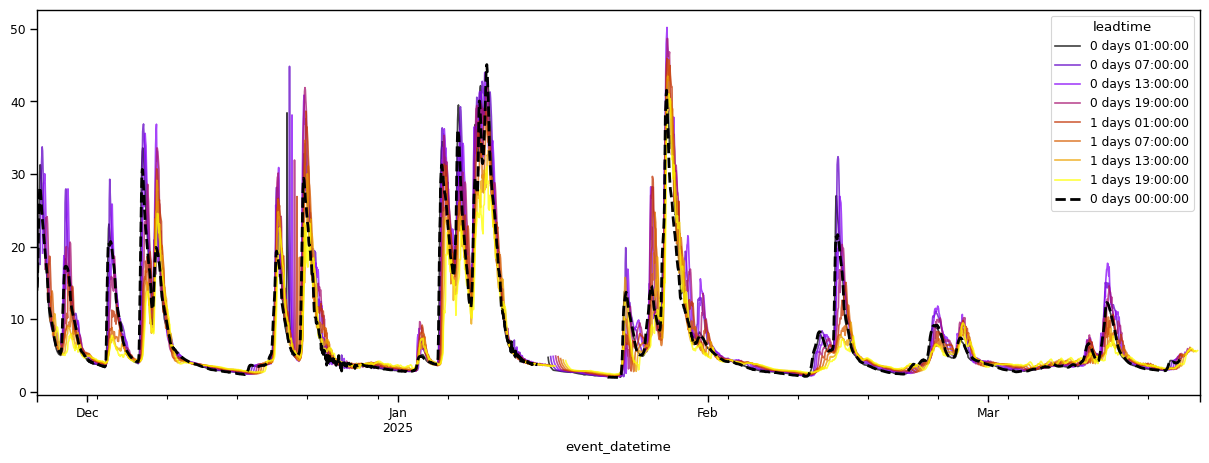

In [4]:
ax = det.iloc[:, ::6].plot(cmap='gnuplot', alpha=0.75, figsize=(15, 5))
_ = obs.plot(color='k', linewidth=2, linestyle='--', ax=ax)

## Create probabilistic forecasts
Heteroscedastinc log-normal distribution whose standard deviation increases with leadtime.  
Created for several probability bands.

In [149]:
norm_ppf

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
1,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
2,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
3,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
4,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130267,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
130268,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
130269,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348
130270,-2.326348,-1.644854,-1.281552,-0.841621,-0.524401,-0.253347,0.0,0.253347,0.524401,0.841621,1.281552,1.644854,2.326348


In [147]:
probability_bands = pd.Index([0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99], name='non_exceedance')
ref_std = pd.DataFrame(np.linspace(np.log(1), np.log(1), det.shape[1]), index=det.columns, columns=['std'])

ref_std_tile = pd.DataFrame(np.tile(ref_std.loc[det_parquet.index.get_level_values('leadtime')].values, (1, len(probability_bands))))
norm_tile = pd.DataFrame(np.tile(scipy.stats.norm(0, 1).ppf(probability_bands), (det_parquet.shape[0], 1)))
norm_ppf = ref_std_tile + norm_tile
tmp = np.log(det_parquet.values) + norm_ppf
tmp = np.exp(tmp)
prob = pd.DataFrame(tmp.values, index=det_parquet.index, columns=probability_bands)

display(prob)

non_exceedance                                               0.01      0.05  \
production_datetime event_datetime      leadtime                              
2024-11-26 00:00:00 2024-11-26 01:00:00 0 days 01:00:00  1.372679  2.713552   
                    2024-11-26 02:00:00 0 days 02:00:00  1.398354  2.764308   
                    2024-11-26 03:00:00 0 days 03:00:00  1.447469  2.861400   
                    2024-11-26 04:00:00 0 days 04:00:00  1.495369  2.956090   
                    2024-11-26 05:00:00 0 days 05:00:00  1.566857  3.097409   
...                                                           ...       ...   
2025-03-20 03:00:00 2025-03-21 23:00:00 1 days 20:00:00  0.558701  1.104456   
                    2025-03-22 00:00:00 1 days 21:00:00  0.560673  1.108355   
                    2025-03-22 01:00:00 1 days 22:00:00  0.562486  1.111938   
                    2025-03-22 02:00:00 1 days 23:00:00  0.563996  1.114925   
                    2025-03-22 03:00:00 2 days 00:00:00  0.565072  1.117050   

non_exceedance                                               0.10      0.20  \
production_datetime event_datetime      leadtime                              
2024-11-26 00:00:00 2024-11-26 01:00:00 0 days 01:00:00  3.902278  6.058673   
                    2024-11-26 02:00:00 0 days 02:00:00  3.975269  6.171998   
                    2024-11-26 03:00:00 0 days 03:00:00  4.114893  6.388780   
                    2024-11-26 04:00:00 0 days 04:00:00  4.251065  6.600199   
                    2024-11-26 05:00:00 0 days 05:00:00  4.454292  6.915730   
...                                                           ...       ...   
2025-03-20 03:00:00 2025-03-21 23:00:00 1 days 20:00:00  1.588285  2.465970   
                    2025-03-22 00:00:00 1 days 21:00:00  1.593893  2.474677   
                    2025-03-22 01:00:00 1 days 22:00:00  1.599045  2.482676   
                    2025-03-22 02:00:00 1 days 23:00:00  1.603340  2.489344   
                    2025-03-22 03:00:00 2 days 00:00:00  1.606396  2.494089   

non_exceedance                                               0.30       0.40  \
production_datetime event_datetime      leadtime                               
2024-11-26 00:00:00 2024-11-26 01:00:00 0 days 01:00:00  8.320409  10.910928   
                    2024-11-26 02:00:00 0 days 02:00:00  8.476040  11.115014   
                    2024-11-26 03:00:00 0 days 03:00:00  8.773747  11.505411   
                    2024-11-26 04:00:00 0 days 04:00:00  9.064091  11.886151   
                    2024-11-26 05:00:00 0 days 05:00:00  9.497411  12.454383   
...                                                           ...        ...   
2025-03-20 03:00:00 2025-03-21 23:00:00 1 days 20:00:00  3.386531   4.440911   
                    2025-03-22 00:00:00 1 days 21:00:00  3.398487   4.456590   
                    2025-03-22 01:00:00 1 days 22:00:00  3.409473   4.470996   
                    2025-03-22 02:00:00 1 days 23:00:00  3.418630   4.483004   
                    2025-03-22 03:00:00 2 days 00:00:00  3.425147   4.491550   

non_exceedance                                               0.50       0.60  \
production_datetime event_datetime      leadtime                               
2024-11-26 00:00:00 2024-11-26 01:00:00 0 days 01:00:00  14.05688  18.109906   
                    2024-11-26 02:00:00 0 days 02:00:00  14.31981  18.448646   
                    2024-11-26 03:00:00 0 days 03:00:00  14.82277  19.096625   
                    2024-11-26 04:00:00 0 days 04:00:00  15.31329  19.728577   
                    2024-11-26 05:00:00 0 days 05:00:00  16.04536  20.671725   
...                                                           ...        ...   
2025-03-20 03:00:00 2025-03-21 23:00:00 1 days 20:00:00   5.72136   7.371002   
                    2025-03-22 00:00:00 1 days 21:00:00   5.74156   7.397026   
                    2025-03-22 01:00:00 1 days 22:00:00   5.76012   7.420938   
                    202

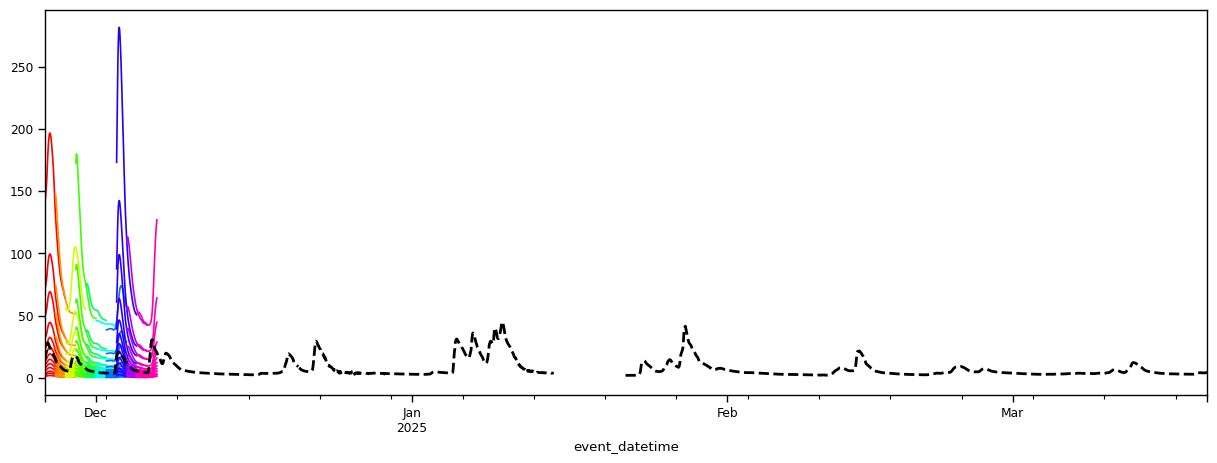

In [148]:
cmap = matplotlib.colormaps['hsv']
ax = None
production_dates = prob.index.get_level_values('production_datetime').unique()
forecast_dates = production_dates[:240:24]
for i0, pdt0 in enumerate(forecast_dates):
    tmp = prob.loc[pdt0, :].droplevel('leadtime').dropna(how='all')
    ax = tmp.plot(ax=ax, color=cmap(int(i0/len(forecast_dates)*256)), alpha=1, figsize=(15, 5), legend=False)

_ = obs.loc[obs.index<=prob.index.get_level_values('event_datetime').max(), :].plot(color='k', linewidth=2, linestyle='--', ax=ax, legend=False)

## Create ensemble forecasts
Based on probabilistic forecasts sampled with autoregressive p-value sampling. 